## Análisis y Predicción de Ventas en una Tienda de Retail

Parte II: Análisis Exploratorio con Pandas

In [2]:
# Importar pandas
import pandas as pd
import os

In [3]:
# Importar datos y convertir a dataframe
# Ruta del archivo CSV que contiene los datos a ser analizados
ruta_archivo = '../data/retail_sales_dataset.csv'
df = pd.read_csv(ruta_archivo)

In [4]:
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [5]:
df.tail(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [8]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [9]:
df['Product Category'].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [10]:
df[df['Total Amount']>50]

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
...,...,...,...,...,...,...,...,...,...
993,994,2023-12-18,CUST994,Female,51,Beauty,2,500,1000
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [11]:
df[df['Price per Unit']<30]

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
11,12,2023-10-30,CUST012,Male,35,Beauty,3,25,75
16,17,2023-04-22,CUST017,Female,27,Clothing,4,25,100
17,18,2023-04-30,CUST018,Female,47,Electronics,2,25,50
...,...,...,...,...,...,...,...,...,...
979,980,2023-07-29,CUST980,Female,31,Electronics,3,25,75
984,985,2023-05-30,CUST985,Female,19,Electronics,2,25,50
987,988,2023-05-28,CUST988,Female,63,Clothing,3,25,75
988,989,2023-12-28,CUST989,Female,44,Electronics,1,25,25


In [12]:
df.query('`Product Category` == "Beauty" & `Total Amount` > 30')

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
11,12,2023-10-30,CUST012,Male,35,Beauty,3,25,75
20,21,2023-01-14,CUST021,Female,50,Beauty,1,500,500
24,25,2023-12-26,CUST025,Female,64,Beauty,1,50,50
...,...,...,...,...,...,...,...,...,...
981,982,2023-12-19,CUST982,Female,46,Beauty,3,30,90
989,990,2023-05-25,CUST990,Female,58,Beauty,2,500,1000
993,994,2023-12-18,CUST994,Female,51,Beauty,2,500,1000
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90


In [13]:
df[['Product Category','Total Amount']]

,Product Category,Total Amount
0,Beauty,150
1,Clothing,1000
2,Electronics,30
3,Clothing,500
4,Beauty,100
...,...,...
995,Clothing,50
996,Beauty,90
997,Beauty,100
998,Electronics,150


In [14]:
df.loc[5:10, ['Product Category', 'Total Amount']]

,Product Category,Total Amount
5,Beauty,30
6,Clothing,50
7,Electronics,100
8,Electronics,600
9,Clothing,200
10,Clothing,100


In [15]:
df.iloc[:5, :3]

,Transaction ID,Date,Customer ID
0,1,2023-11-24,CUST001
1,2,2023-02-27,CUST002
2,3,2023-01-13,CUST003
3,4,2023-05-21,CUST004
4,5,2023-05-06,CUST005


## Análisis y Predicción de Ventas en una Tienda de Retail

Parte III: Transformación y Análisis Avanzado de Datos con Pandas

In [16]:
# Calcular el ingreso total por transacción
df['Total Amount'] = df['Quantity'] * df['Price per Unit']

# Normalizar el total de ventas
df['ventas_normalizadas'] = (df['Total Amount'] - df['Total Amount'].mean()) / df['Total Amount'].std()

# Mostrar las primeras filas del DataFrame con las nuevas columnas
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,ventas_normalizadas
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,-0.546431
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,0.971433
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,-0.760718
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,0.078572
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,-0.635717


In [17]:
# Normalizar el total de ventas a un rango de 0 a 1
min_val = df['Total Amount'].min()
max_val = df['Total Amount'].max()

df['ventas_normalizadas'] = (df['Total Amount'] - min_val) / (max_val - min_val)

# Mostrar las primeras filas del DataFrame con las nuevas columnas
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,ventas_normalizadas
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,0.063291
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,0.493671
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,0.002532
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,0.240506
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,0.037975


In [18]:
# Definir las categorías según los cuartiles
def clasificar_ventas(total_amount):
    if total_amount >= df['Total Amount'].quantile(0.75):
        return 'Alta'
    elif total_amount >= df['Total Amount'].quantile(0.25):
        return 'Media'
    else:
        return 'Baja'

# Aplicar la función para crear una nueva columna 'Clasificación'
df['Clasificación'] = df['Total Amount'].apply(clasificar_ventas)

# Mostrar las primeras filas del DataFrame con la nueva columna
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,ventas_normalizadas,Clasificación
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,0.063291,Media
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,0.493671,Alta
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,0.002532,Baja
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,0.240506,Media
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,0.037975,Media


In [19]:
# Convertir la columna 'Date' a tipo datetime
df['Date'] = pd.to_datetime(df['Date'])

# Crear una columna para el mes
df['Mes'] = df['Date'].dt.to_period('M')

# Agrupar por 'Product Category' y 'Mes', y calcular el total de ventas
agrupacion_producto_mes = df.groupby(['Product Category', 'Mes'])['Total Amount'].sum().reset_index()

# Mostrar el resultado
print(agrupacion_producto_mes)

   Product Category      Mes  Total Amount
0            Beauty  2023-01         12430
1            Beauty  2023-02         14035
2            Beauty  2023-03         10545
3            Beauty  2023-04         11905
4            Beauty  2023-05         12450
5            Beauty  2023-06         10995
6            Beauty  2023-07         16090
7            Beauty  2023-08          9790
8            Beauty  2023-09          6320
9            Beauty  2023-10         15355
10           Beauty  2023-11          9700
11           Beauty  2023-12         12400
12           Beauty  2024-01          1500
13         Clothing  2023-01         13125
14         Clothing  2023-02         14560
15         Clothing  2023-03         15065
16         Clothing  2023-04         13940
17         Clothing  2023-05         17455
18         Clothing  2023-06         10170
19         Clothing  2023-07          8250
20         Clothing  2023-08         12455
21         Clothing  2023-09          9975
22         

In [20]:
# Agrupar por 'Rango de Edad' y 'Gender', y calcular estadísticas descriptivas
estadisticas_genero_edad = df.groupby(['Rango de Edad', 'Gender']).agg(
    total_ventas=('Total Amount', 'sum'),
    promedio_ventas=('Total Amount', 'mean'),
    conteo_transacciones=('Transaction ID', 'count'),
    min_venta=('Total Amount', 'min'),
    max_venta=('Total Amount', 'max'),
    desviacion_estandar=('Total Amount', 'std'),
    varianza=('Total Amount', 'var')
).reset_index()

# Mostrar el resultado
print(estadisticas_genero_edad)

KeyError: 'Rango de Edad'

In [26]:
# Definir la función personalizada para clasificación compleja
def clasificar_ventas_compleja(x):
    if x < 50:
        return 'Baja'
    elif 50 <= x < 200:
        return 'Media'
    else:
        return 'Alta'

# Agrupar por 'Product Category' y aplicar la función personalizada
df['Clasificación Compleja'] = df['Total Amount'].apply(clasificar_ventas_compleja)

# Mostrar las primeras filas del DataFrame con la nueva clasificación
print(df.head())

   Transaction ID       Date Customer ID  Gender  Age Product Category  \
0               1 2023-11-24     CUST001    Male   34           Beauty   
1               2 2023-02-27     CUST002  Female   26         Clothing   
2               3 2023-01-13     CUST003    Male   50      Electronics   
3               4 2023-05-21     CUST004    Male   37         Clothing   
4               5 2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  ventas_normalizadas Clasificación  \
0         3              50           150             0.063291         Media   
1         2             500          1000             0.493671          Alta   
2         1              30            30             0.002532          Baja   
3         1             500           500             0.240506         Media   
4         2              50           100             0.037975         Media   

  Rango de Edad      Mes Clasificación Compleja  
0        Adulto  2023-11

In [27]:
# Calcular la media del Total Amount por Product Category
media_ventas = df.groupby('Product Category')['Total Amount'].mean().reset_index()
media_ventas.columns = ['Product Category', 'Media Ventas']

# Unir la media de ventas con el DataFrame original
df = df.merge(media_ventas, on='Product Category')

# Calcular la desviación de cada venta respecto a la media de su grupo
df['Desviación Respecto a la Media'] = df['Total Amount'] - df['Media Ventas']

# Mostrar las primeras filas del DataFrame con la nueva columna
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,ventas_normalizadas,Clasificación,Rango de Edad,Mes,Clasificación Compleja,Media Ventas,Desviación Respecto a la Media
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,0.063291,Media,Adulto,2023-11,Media,467.475570,-317.475570
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,0.493671,Alta,Adulto,2023-02,Alta,443.247863,556.752137
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,0.002532,Baja,Mayor,2023-01,Baja,458.786550,-428.786550
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,0.240506,Media,Adulto,2023-05,Alta,443.247863,56.752137
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,0.037975,Media,Adulto,2023-05,Media,467.475570,-367.475570


### Continuar desde la Parte III

In [21]:
# Calcular estadísticas descriptivas básicas
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,ventas_normalizadas
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,0.218228
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,0.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,0.017722
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,0.055696
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,0.443038
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,1.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,0.283543


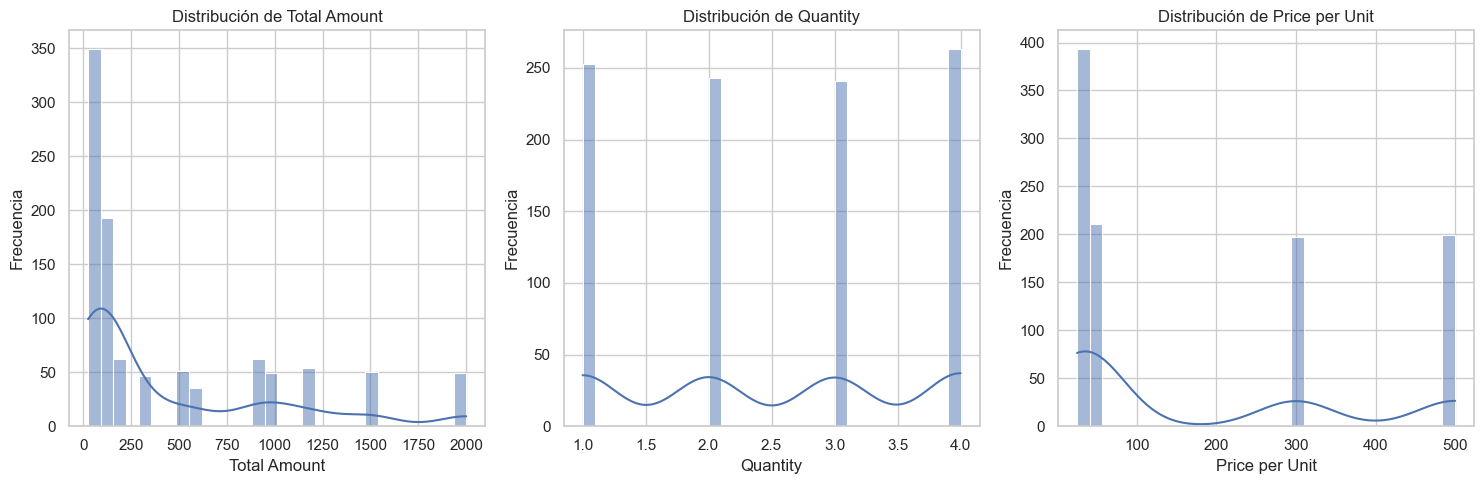

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo de seaborn
sns.set(style="whitegrid")

# Crear histogramas
plt.figure(figsize=(15, 5))

# Histograma de Total Amount
plt.subplot(1, 3, 1)
sns.histplot(df['Total Amount'], bins=30, kde=True)
plt.title('Distribución de Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frecuencia')

# Histograma de Quantity
plt.subplot(1, 3, 2)
sns.histplot(df['Quantity'], bins=30, kde=True)
plt.title('Distribución de Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frecuencia')

# Histograma de Price per Unit
plt.subplot(1, 3, 3)
sns.histplot(df['Price per Unit'], bins=30, kde=True)
plt.title('Distribución de Price per Unit')
plt.xlabel('Price per Unit')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

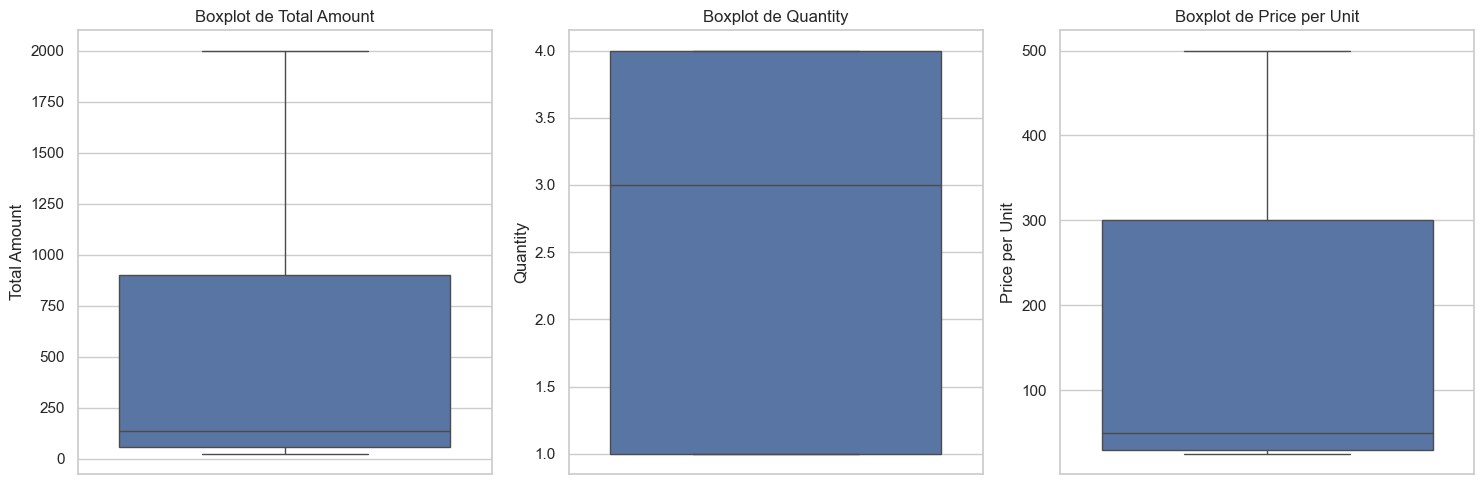

In [24]:
# Crear boxplots
plt.figure(figsize=(15, 5))

# Boxplot de Total Amount
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Total Amount'])
plt.title('Boxplot de Total Amount')

# Boxplot de Quantity
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Quantity'])
plt.title('Boxplot de Quantity')

# Boxplot de Price per Unit
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Price per Unit'])
plt.title('Boxplot de Price per Unit')

plt.tight_layout()
plt.show()

In [25]:
# Agrupar por 'Mes' y calcular el total de ventas
ventas_por_mes = df.groupby('Mes')['Total Amount'].sum().reset_index()
# Convertir la columna 'Mes' a tipo datetime para facilitar el graficado
ventas_por_mes['Mes'] = ventas_por_mes['Mes'].dt.to_timestamp()

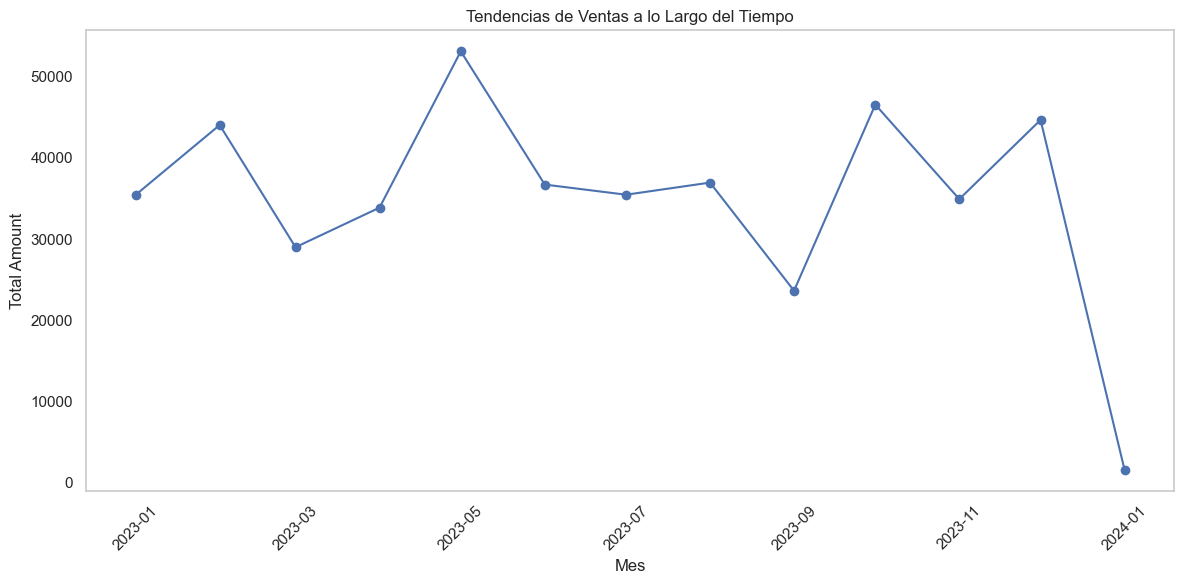

In [27]:
# Crear gráfico de líneas
plt.figure(figsize=(12, 6))
plt.plot(ventas_por_mes['Mes'], ventas_por_mes['Total Amount'], marker='o', color='b', linestyle='-')
plt.title('Tendencias de Ventas a lo Largo del Tiempo')
plt.xlabel('Mes')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

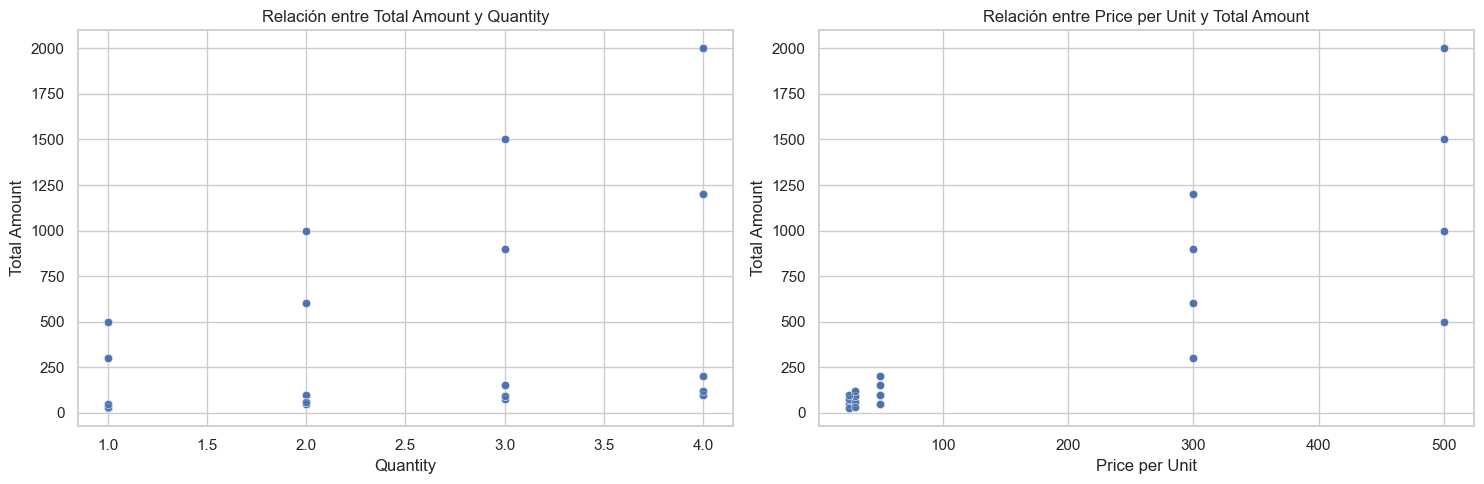

In [28]:
# Configuración de estilo de seaborn
sns.set(style="whitegrid")

# Crear gráficos de dispersión
plt.figure(figsize=(15, 5))

# Gráfico de dispersión de Total Amount vs Quantity
plt.subplot(1, 2, 1)
sns.scatterplot(x='Quantity', y='Total Amount', data=df, alpha=0.7)
plt.title('Relación entre Total Amount y Quantity')
plt.xlabel('Quantity')
plt.ylabel('Total Amount')

# Gráfico de dispersión de Price per Unit vs Total Amount
plt.subplot(1, 2, 2)
sns.scatterplot(x='Price per Unit', y='Total Amount', data=df, alpha=0.7)
plt.title('Relación entre Price per Unit y Total Amount')
plt.xlabel('Price per Unit')
plt.ylabel('Total Amount')

plt.tight_layout()
plt.show()

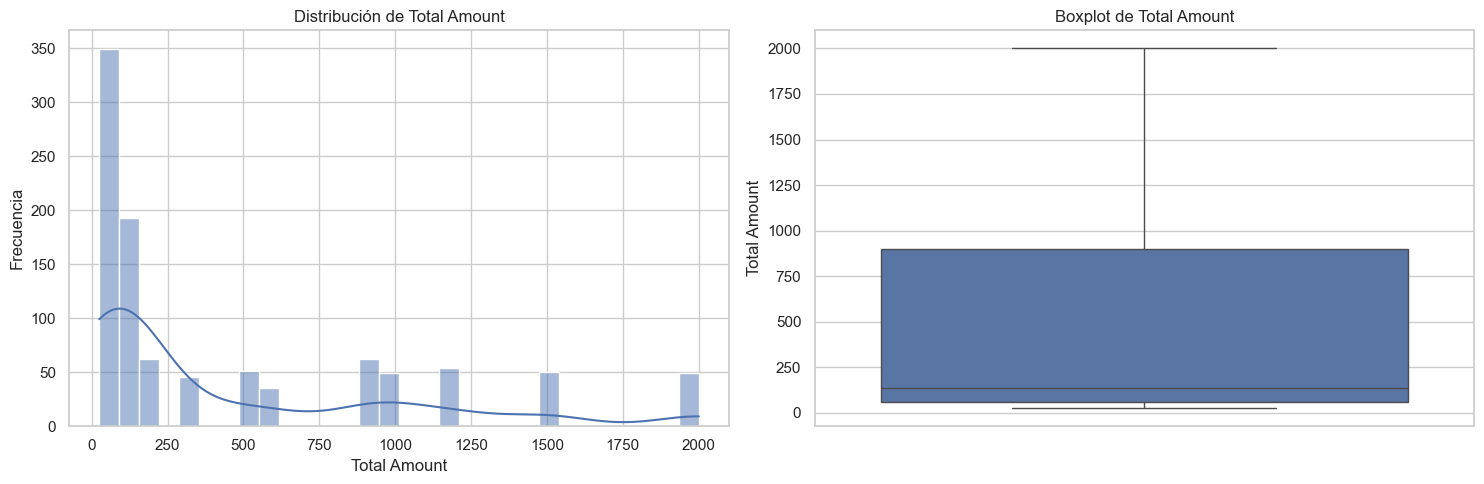

In [29]:
# Configuración de estilo de seaborn
sns.set(style="whitegrid")

# Crear histogramas y boxplots
plt.figure(figsize=(15, 5))

# Histograma de Total Amount
plt.subplot(1, 2, 1)
sns.histplot(df['Total Amount'], bins=30, kde=True)
plt.title('Distribución de Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frecuencia')

# Boxplot de Total Amount
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Total Amount'])
plt.title('Boxplot de Total Amount')

plt.tight_layout()
plt.show()